# Milestone 2 - Simplified NBA Recommendation Pipeline

## Research Question
How can an LLM-assisted pipeline parse a user's NBA roster request, diagnose a team's weaknesses from recent performance statistics, and recommend players whose statistical strengths best match those needs?

## Simplified Pipeline
1. **LLM Parsing**  
   Turn a natural-language query into structured fields like team, goal, top-k, recent games, and filters.

2. **Tool A: Team Need Diagnosis**  
   Use recent team performance and z-scores to find what the team lacks.

3. **Tool B: Player Strength Representation**  
   Use player box-score statistics to build simple strength vectors.

4. **Tool C: Fit Ranking**  
   Match team needs with player strengths and rank the best-fit players.

5. **LLM Summary Generation**  
   Write a short scouting-style summary from the structured results.

6. **Automatic Charts**  
   Generate charts directly from the computed tables.

## Upload files

For this simple milestone 2 version, we mainly use:

- `teams.csv`
- `games.csv`
- `games_details.csv`



In [3]:
from google.colab import files

uploaded = files.upload()

Saving teams.csv to teams (1).csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving games.csv to games.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving games_details.csv to games_details.csv


## OpenRouter setup



This notebook uses:
- model = `qwen/qwen3.6-plus-preview:free`

The LLM is used only for:
1. parsing the user query at the beginning
2. generating the final summary at the end

In [6]:
import os

os.environ["OPENROUTER_API_KEY"] = "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"

MODEL_NAME = "qwen/qwen3.6-plus-preview:free"

In [12]:
import os
import re
import json
import html
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML

# -----------------------------
# pandas display settings
# -----------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 3000)

# -----------------------------
# helper display functions
# -----------------------------
def show_wrapped_text(title, text):
    safe_text = html.escape(str(text))
    display(HTML(f"""
    <div style="
        border:1px solid #cccccc;
        padding:12px;
        margin:10px 0;
        border-radius:8px;
        background:#fafafa;
        white-space:pre-wrap;
        word-break:break-word;
        line-height:1.5;
        font-family:monospace;
        font-size:14px;
    ">
    <b>{html.escape(title)}</b><br><br>
    {safe_text}
    </div>
    """))

def show_df(title, df, max_rows=None):
    print(f"\n{title}")
    if max_rows is None:
        display(df)
    else:
        display(df.head(max_rows))

# -----------------------------
# load files
# -----------------------------
BASE_PATH = "/content"

teams = pd.read_csv(f"{BASE_PATH}/teams.csv")
games = pd.read_csv(f"{BASE_PATH}/games.csv")
games_details = pd.read_csv(f"{BASE_PATH}/games_details.csv", low_memory=False)

games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"])

# -----------------------------
# clean numeric columns
# -----------------------------
NUM_COLS = [
    "FGM", "FGA", "FG3M", "FG3A", "FTM", "FTA",
    "OREB", "DREB", "REB", "AST", "STL", "BLK",
    "TO", "PF", "PTS", "PLUS_MINUS"
]

for col in NUM_COLS:
    games_details[col] = pd.to_numeric(games_details[col], errors="coerce").fillna(0)

# -----------------------------
# parse minutes
# -----------------------------
def parse_minutes(x):
    if pd.isna(x):
        return 0.0
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return 0.0
    if ":" in s:
        try:
            m, sec = s.split(":")
            return float(m) + float(sec) / 60.0
        except:
            return 0.0
    try:
        return float(s)
    except:
        return 0.0

games_details["MIN_FLOAT"] = games_details["MIN"].apply(parse_minutes)
games_details = games_details[games_details["MIN_FLOAT"] > 0].copy()

# -----------------------------
# merge date and season
# -----------------------------
games_small = games[["GAME_ID", "GAME_DATE_EST", "SEASON", "HOME_TEAM_ID", "VISITOR_TEAM_ID"]].copy()

player_game_df = games_details.merge(
    games_small[["GAME_ID", "GAME_DATE_EST", "SEASON"]],
    on="GAME_ID",
    how="left"
)

# -----------------------------
# team mapping
# -----------------------------
teams["TEAM_NAME_FULL"] = (teams["CITY"].fillna("") + " " + teams["NICKNAME"].fillna("")).str.strip()

team_name_map = dict(zip(teams["TEAM_ID"], teams["TEAM_NAME_FULL"]))
team_abbr_map = dict(zip(teams["TEAM_ID"], teams["ABBREVIATION"]))

TEAM_LOOKUP = {}

for _, row in teams.iterrows():
    keys = [
        str(row["TEAM_ID"]),
        str(row["ABBREVIATION"]),
        str(row["NICKNAME"]),
        str(row["CITY"]),
        str(row["TEAM_NAME_FULL"])
    ]
    for key in keys:
        TEAM_LOOKUP[key.lower()] = int(row["TEAM_ID"])

def find_team_id(team_text):
    if team_text is None:
        raise ValueError("No team name found in query.")

    key = str(team_text).strip().lower()

    if key in TEAM_LOOKUP:
        return TEAM_LOOKUP[key]

    for k, v in TEAM_LOOKUP.items():
        if key in k:
            return v

    raise ValueError(f"Could not match team name: {team_text}")

print("teams shape:", teams.shape)
print("games shape:", games.shape)
print("games_details shape:", games_details.shape)

display(teams[["TEAM_ID", "ABBREVIATION", "TEAM_NAME_FULL"]].head())

teams shape: (30, 15)
games shape: (26651, 21)
games_details shape: (558746, 30)


,TEAM_ID,ABBREVIATION,TEAM_NAME_FULL
0,1610612737,ATL,Atlanta Hawks
1,1610612738,BOS,Boston Celtics
2,1610612740,NOP,New Orleans Pelicans
3,1610612741,CHI,Chicago Bulls
4,1610612742,DAL,Dallas Mavericks


## LLM parsing

This step turns a human query into a simple JSON object.

Example:
- team
- goal
- top_k
- recent_games
- min_games
- min_avg_minutes
- exclude_current_team



In [13]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")

DEFAULTS = {
    "team": "Warriors",
    "goal": "",
    "top_k": 5,
    "recent_games": 10,
    "min_games": 15,
    "min_avg_minutes": 15,
    "exclude_current_team": True
}

def call_openrouter(messages, model=MODEL_NAME, temperature=0):
    if not OPENROUTER_API_KEY:
        raise ValueError("OPENROUTER_API_KEY is empty.")

    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://colab.research.google.com",
        "X-Title": "NBA Milestone 2"
    }

    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature
    }

    r = requests.post(url, headers=headers, json=payload, timeout=120)
    r.raise_for_status()
    data = r.json()
    return data["choices"][0]["message"]["content"]

def extract_json_object(text):
    text = text.strip()

    try:
        return json.loads(text)
    except:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            pass

    return None

def fallback_parse_query(user_query):
    parsed = DEFAULTS.copy()
    q = user_query.lower()

    for _, row in teams.iterrows():
        possible = [
            str(row["NICKNAME"]).lower(),
            str(row["ABBREVIATION"]).lower(),
            str(row["TEAM_NAME_FULL"]).lower(),
            str(row["CITY"]).lower(),
        ]
        for p in possible:
            if p and p in q:
                parsed["team"] = row["TEAM_NAME_FULL"]
                break

    goal_list = [
        "interior defense",
        "rim protection",
        "rebounding",
        "playmaking",
        "perimeter defense",
        "three-point shooting",
        "shooting"
    ]

    for g in goal_list:
        if g in q:
            parsed["goal"] = g
            break

    m = re.search(r"top\s*(\d+)", q)
    if m:
        parsed["top_k"] = int(m.group(1))

    m = re.search(r"(last|recent)\s*(\d+)\s*games", q)
    if m:
        parsed["recent_games"] = int(m.group(2))

    m = re.search(r"at least\s*(\d+)\s*games", q)
    if m:
        parsed["min_games"] = int(m.group(1))

    m = re.search(r"at least\s*(\d+)\s*(avg|average)?\s*minutes", q)
    if m:
        parsed["min_avg_minutes"] = int(m.group(1))

    return parsed

def parse_user_query(user_query, return_raw=False):
    prompt = f"""
You are extracting structured fields from an NBA roster recommendation request.

Return only valid JSON with these keys:
team, goal, top_k, recent_games, min_games, min_avg_minutes, exclude_current_team

Rules:
- team: team name text only
- goal: short phrase, can be empty string
- top_k: integer
- recent_games: integer
- min_games: integer
- min_avg_minutes: integer
- exclude_current_team: true or false

If user does not specify a field, use these defaults:
{json.dumps(DEFAULTS)}

User query:
{user_query}
"""

    raw = None

    try:
        raw = call_openrouter(
            [
                {"role": "system", "content": "You extract JSON only."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        parsed = extract_json_object(raw)
        if parsed is None:
            parsed = fallback_parse_query(user_query)
    except Exception as e:
        raw = f"[Fallback parser used because API failed]\n{str(e)}"
        parsed = fallback_parse_query(user_query)

    out = DEFAULTS.copy()
    out.update(parsed)

    out["top_k"] = int(out["top_k"])
    out["recent_games"] = int(out["recent_games"])
    out["min_games"] = int(out["min_games"])
    out["min_avg_minutes"] = int(out["min_avg_minutes"])
    out["exclude_current_team"] = bool(out["exclude_current_team"])

    if return_raw:
        return out, raw
    return out

## Tool A, Tool B, Tool C

### Tool A: Team Need Diagnosis
- build recent team averages
- compare with league averages
- use z-score
- convert below-average performance into need weights

### Tool B: Player Strength Representation
- use direct player box-score statistics
- standardize each player on the same dimensions

### Tool C: Fit Ranking
- compute fit score using team needs and player strengths
- return Top-K recommendations

In [14]:
# -----------------------------
# build team-game table
# -----------------------------
team_game_df = (
    player_game_df
    .groupby(["GAME_ID", "TEAM_ID"], as_index=False)
    .agg({
        "REB": "sum",
        "AST": "sum",
        "STL": "sum",
        "BLK": "sum",
        "FG3M": "sum",
        "FG3A": "sum",
        "PTS": "sum"
    })
    .merge(games_small, on="GAME_ID", how="left")
)

team_game_df["FG3_PCT"] = np.where(
    team_game_df["FG3A"] > 0,
    team_game_df["FG3M"] / team_game_df["FG3A"],
    0
)

# -----------------------------
# metric definitions
# -----------------------------
CORE_METRICS = ["REB", "AST", "STL", "BLK", "FG3_PCT"]

CORE_METRIC_LABELS = {
    "REB": "Rebounding",
    "AST": "Playmaking",
    "STL": "Perimeter Defense",
    "BLK": "Rim Protection",
    "FG3_PCT": "Three-Point Shooting"
}

RADAR_METRICS = ["PTS", "AST", "REB", "STL", "BLK", "FG3_PCT"]

RADAR_LABELS = {
    "PTS": "Scoring",
    "AST": "Playmaking",
    "REB": "Rebounding",
    "STL": "Perimeter Defense",
    "BLK": "Rim Protection",
    "FG3_PCT": "Three-Point Shooting"
}

# -----------------------------
# Tool A
# -----------------------------
def tool_a_team_need_diagnosis(team_id, season, recent_games=10):
    team_part = team_game_df[
        (team_game_df["TEAM_ID"] == team_id) &
        (team_game_df["SEASON"] == season)
    ].sort_values("GAME_DATE_EST")

    if len(team_part) == 0:
        raise ValueError("No team games found for this team/season.")

    team_recent = team_part.tail(recent_games)

    league_recent = (
        team_game_df[team_game_df["SEASON"] == season]
        .sort_values("GAME_DATE_EST")
        .groupby("TEAM_ID", as_index=False)
        .tail(recent_games)
        .groupby("TEAM_ID", as_index=False)[CORE_METRICS]
        .mean()
    )

    team_values = team_recent[CORE_METRICS].mean()
    league_mean = league_recent[CORE_METRICS].mean()
    league_std = league_recent[CORE_METRICS].std(ddof=0).replace(0, 1)

    z_scores = (team_values - league_mean) / league_std
    need_weights = (-z_scores).clip(lower=0)

    need_df = pd.DataFrame({
        "metric": CORE_METRICS,
        "label": [CORE_METRIC_LABELS[m] for m in CORE_METRICS],
        "team_value": [team_values[m] for m in CORE_METRICS],
        "league_mean": [league_mean[m] for m in CORE_METRICS],
        "z_score": [z_scores[m] for m in CORE_METRICS],
        "need_weight": [need_weights[m] for m in CORE_METRICS],
    }).sort_values("need_weight", ascending=False).reset_index(drop=True)

    return need_df

# -----------------------------
# optional goal boost
# -----------------------------
GOAL_MAP = {
    "interior defense": ["BLK", "REB"],
    "rim protection": ["BLK"],
    "rebounding": ["REB"],
    "playmaking": ["AST"],
    "perimeter defense": ["STL"],
    "three-point shooting": ["FG3_PCT"],
    "shooting": ["FG3_PCT"]
}

def apply_goal_boost(need_df, goal_text, boost=1.5):
    out = need_df.copy()
    out["goal_boosted"] = False

    if not goal_text:
        return out

    goal_lower = goal_text.lower().strip()
    boosted_metrics = set()

    for key, metrics in GOAL_MAP.items():
        if key in goal_lower:
            boosted_metrics.update(metrics)

    if len(boosted_metrics) > 0:
        mask = out["metric"].isin(boosted_metrics)
        out.loc[mask, "need_weight"] = out.loc[mask, "need_weight"] * boost
        out.loc[mask, "goal_boosted"] = True

    return out.sort_values("need_weight", ascending=False).reset_index(drop=True)

# -----------------------------
# Tool B
# -----------------------------
def tool_b_player_strengths(season, min_games=15, min_avg_minutes=15):
    season_df = player_game_df[player_game_df["SEASON"] == season].copy()

    player_summary = (
        season_df
        .groupby(["PLAYER_ID", "PLAYER_NAME", "TEAM_ID"], as_index=False)
        .agg({
            "GAME_ID": pd.Series.nunique,
            "MIN_FLOAT": "mean",
            "PTS": "mean",
            "REB": "mean",
            "AST": "mean",
            "STL": "mean",
            "BLK": "mean",
            "FG3M": "mean",
            "FG3A": "mean"
        })
        .rename(columns={"GAME_ID": "GP", "MIN_FLOAT": "AVG_MIN"})
    )

    player_summary["FG3_PCT"] = np.where(
        player_summary["FG3A"] > 0,
        player_summary["FG3M"] / player_summary["FG3A"],
        0
    )

    player_summary = player_summary[
        (player_summary["GP"] >= min_games) &
        (player_summary["AVG_MIN"] >= min_avg_minutes)
    ].copy()

    # strength z-scores for ranking + interpretation
    core_means = player_summary[CORE_METRICS].mean()
    core_stds = player_summary[CORE_METRICS].std(ddof=0).replace(0, 1)

    z_strength = (player_summary[CORE_METRICS] - core_means) / core_stds
    z_strength = z_strength.clip(lower=0)

    for m in CORE_METRICS:
        player_summary[f"{m}_strength"] = z_strength[m]

    # radar scores: percentile 0~100 for 6 dimensions
    for m in RADAR_METRICS:
        player_summary[f"{m}_radar"] = player_summary[m].rank(pct=True) * 100

    player_summary["CURRENT_TEAM"] = player_summary["TEAM_ID"].map(team_name_map)
    return player_summary

# -----------------------------
# Tool C
# -----------------------------
def tool_c_rank_players(team_id, need_df, player_strength_df, top_k=5, exclude_current_team=True):
    candidates = player_strength_df.copy()

    if exclude_current_team:
        candidates = candidates[candidates["TEAM_ID"] != team_id].copy()

    need_map = dict(zip(need_df["metric"], need_df["need_weight"]))

    candidates["fit_score"] = 0.0
    for m in CORE_METRICS:
        candidates["fit_score"] += need_map.get(m, 0) * candidates[f"{m}_strength"]

    def best_match(row):
        part = {}
        for m in CORE_METRICS:
            score = need_map.get(m, 0) * row[f"{m}_strength"]
            part[CORE_METRIC_LABELS[m]] = score

        best_two = sorted(part.items(), key=lambda x: x[1], reverse=True)[:2]
        best_two = [x[0] for x in best_two if x[1] > 0]

        if len(best_two) == 0:
            return "General fit"
        return " + ".join(best_two)

    candidates["best_match"] = candidates.apply(best_match, axis=1)

    out = candidates.sort_values("fit_score", ascending=False).reset_index(drop=True)
    return out.head(top_k)

# -----------------------------
# charts
# -----------------------------
def plot_team_needs(need_df, team_name):
    plt.figure(figsize=(8, 4))
    plt.bar(need_df["label"], need_df["need_weight"])
    plt.title(f"{team_name} - Team Need Weights")
    plt.ylabel("Need Weight")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

def plot_top_players(ranked_df):
    plt.figure(figsize=(8, 4))
    plt.bar(ranked_df["PLAYER_NAME"], ranked_df["fit_score"])
    plt.title("Top Player Recommendations")
    plt.ylabel("Fit Score")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

def plot_player_radar(player_row, title=None):
    labels = [RADAR_LABELS[m] for m in RADAR_METRICS]
    values = [player_row[f"{m}_radar"] for m in RADAR_METRICS]

    # close the polygon
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values = values + values[:1]
    angles = angles + angles[:1]

    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"])
    ax.set_ylim(0, 100)

    if title is None:
        title = f"{player_row['PLAYER_NAME']} Ability Radar"
    ax.set_title(title, y=1.08)

    plt.tight_layout()
    plt.show()

def plot_top_player_radars(ranked_df, player_strength_df, top_n=3):
    top_names = ranked_df["PLAYER_NAME"].head(top_n).tolist()

    for name in top_names:
        row = player_strength_df[player_strength_df["PLAYER_NAME"] == name].head(1)
        if len(row) > 0:
            plot_player_radar(row.iloc[0], title=f"{name} - Ability Radar")

## Final LLM summary

LLM only reads:
- parsed query
- Tool A output
- Tool C output

Then it writes one short scouting-style paragraph.

In [15]:
def fallback_summary(team_name, parsed, need_df, ranked_df):
    top_needs = need_df.sort_values("need_weight", ascending=False).head(3)["label"].tolist()
    top_players = ranked_df["PLAYER_NAME"].tolist()

    return (
        f"Team: {team_name}\n"
        f"Goal: {parsed['goal'] if parsed['goal'] else 'None'}\n"
        f"Main needs: {', '.join(top_needs)}\n"
        f"Recommended players: {', '.join(top_players)}\n"
        f"This result comes from Tool A team need diagnosis, Tool B player strengths, and Tool C fit ranking."
    )

def generate_llm_summary(team_name, parsed, need_df, ranked_df, return_raw=False):
    need_records = need_df[["label", "z_score", "need_weight", "goal_boosted"]].to_dict(orient="records")
    rank_records = ranked_df[["PLAYER_NAME", "CURRENT_TEAM", "fit_score", "best_match"]].to_dict(orient="records")

    prompt = f"""
Write a short milestone-2 scouting summary.

Team: {team_name}
Parsed query: {json.dumps(parsed, ensure_ascii=False)}
Team needs: {json.dumps(need_records, ensure_ascii=False)}
Top recommendations: {json.dumps(rank_records, ensure_ascii=False)}

Instructions:
- 1 short paragraph
- say what the team lacks
- say why the top players fit
- mention that ranking is based on statistical fit, not salary/trade realism
- do not use bullet points
"""

    raw = None

    try:
        raw = call_openrouter(
            [
                {"role": "system", "content": "You are a concise sports analytics writer."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2
        )
        summary_text = raw
    except Exception as e:
        raw = f"[Fallback summary used because API failed]\n{str(e)}"
        summary_text = fallback_summary(team_name, parsed, need_df, ranked_df)

    if return_raw:
        return summary_text, raw
    return summary_text

## Full Pipeline Demo

This section shows the full end-to-end flow:

1. user input  
2. LLM parsing  
3. Tool A team need diagnosis  
4. Tool B player strength representation  
5. Tool C fit ranking  
6. automatic charts  
7. player ability radar charts  
8. LLM final summary

STEP 0 - USER INPUT


STEP 1 - LLM PARSING



Structured Parsed Query


,team,goal,top_k,recent_games,min_games,min_avg_minutes,exclude_current_team
0,Warriors,improve interior defense,5,10,20,18,True


STEP 2 - TOOL A: TEAM NEED DIAGNOSIS
Tool A uses recent team statistics and z-scores to identify below-average dimensions.

Tool A Output - Team Need Diagnosis


...

STEP 4 - TOOL C: FIT RANKING
Tool C ranks players by matching team needs with player strengths.

Tool C Output - Top Recommendations


,PLAYER_NAME,CURRENT_TEAM,GP,AVG_MIN,fit_score,best_match
0,Anthony Davis,Los Angeles Lakers,28,32.145,7.388,Rebounding + Rim Protection
1,Rudy Gobert,Minnesota Timberwolves,29,30.795,5.286,Rebounding + Rim Protection
2,O.G. Anunoby,Toronto Raptors,33,34.776,5.032,Perimeter Defense + Rim Protection
3,Nikola Jokic,Denver Nuggets,30,31.489,5.024,Rebounding + Perimeter Defense
4,Joel Embiid,Philadelphia 76ers,24,34.539,4.863,Rebounding + Rim Protection



Tool C Output - Full Candidate Ranking


,PLAYER_NAME,CURRENT_TEAM,GP,AVG_MIN,fit_score,best_match
0,Anthony Davis,Los Angeles Lakers,28,32.145,7.388,Rebounding + Rim Protection
1,Rudy Gobert,Minnesota Timberwolves,29,30.795,5.286,Rebounding + Rim Protection
2,O.G. Anunoby,Toronto Raptors,33,34.776,5.032,Perimeter Defense + Rim Protection
3,Nikola Jokic,Denver Nuggets,30,31.489,5.024,Rebounding + Perimeter Defense
4,Joel Embiid,Philadelphia 76ers,24,34.539,4.863,Rebounding + Rim Protection
5,Clint Capela,Atlanta Hawks,29,26.961,4.615,Rebounding + Rim Protection
6,Luka Doncic,Dallas Mavericks,31,35.560,4.417,Perimeter Defense + Rebounding
7,Nic Claxton,Brooklyn Nets,33,26.816,4.375,Rim Protection + Rebounding
8,Ivica Zubac,Los Angeles Clippers,34,28.191,4.240,Rebounding + Rim Protection
9,De'Anthony Melton,Philadelphia 76ers,31,28.431,4.199,Perimeter Defense


STEP 5 - AUTO-GENERATED CHARTS


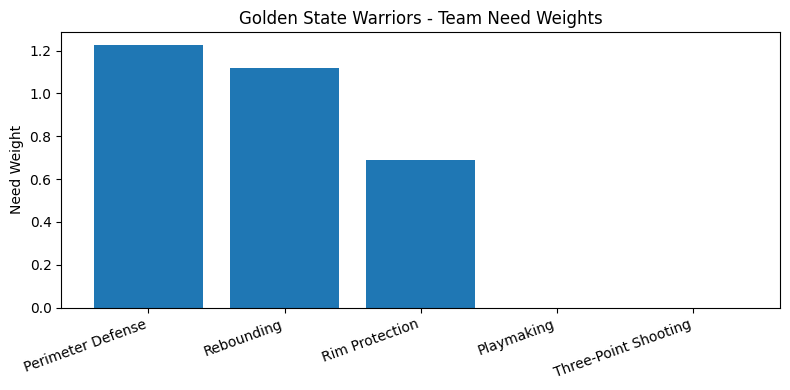

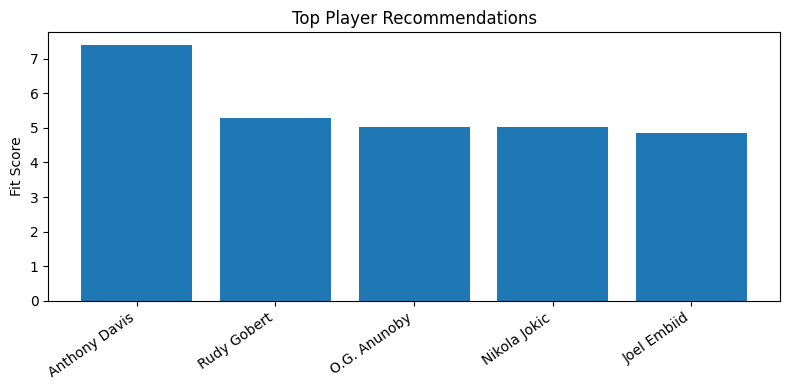

STEP 6 - PLAYER ABILITY RADAR CHARTS
These radar charts visualize the ability profile of the top recommended players.


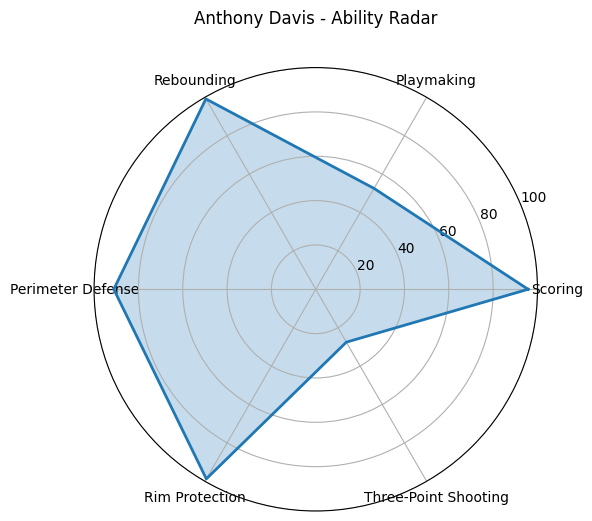

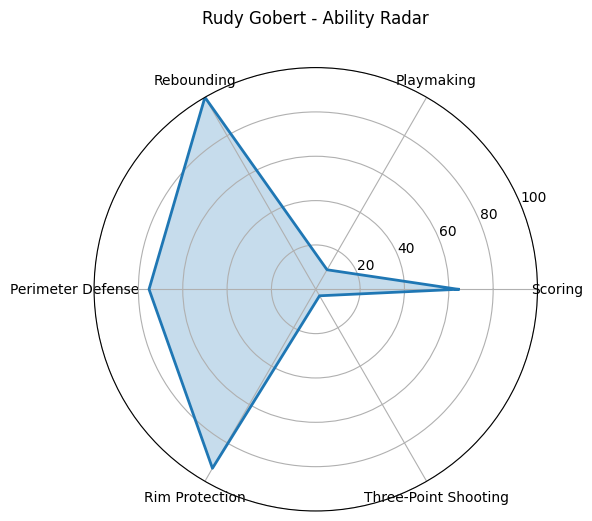

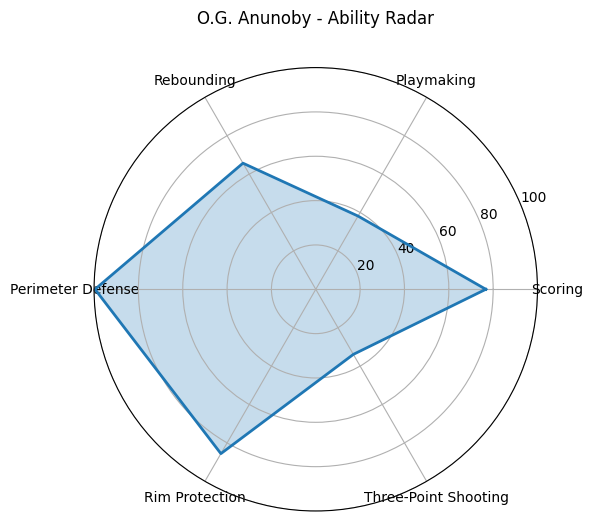

STEP 7 - LLM FINAL SUMMARY


In [16]:
DEFAULT_SEASON = int(games["SEASON"].max())

user_query = "Recommend top 5 players for the Warriors to improve interior defense using the last 10 games. Only include players with at least 20 games and 18 average minutes."

print("=" * 80)
print("STEP 0 - USER INPUT")
print("=" * 80)
show_wrapped_text("User Query", user_query)

# -----------------------------
# STEP 1 - LLM parsing
# -----------------------------
print("=" * 80)
print("STEP 1 - LLM PARSING")
print("=" * 80)

parsed, raw_parse_output = parse_user_query(user_query, return_raw=True)

show_wrapped_text("Raw LLM Parsing Output", raw_parse_output)
show_df("Structured Parsed Query", pd.DataFrame([parsed]))

# -----------------------------
# team info
# -----------------------------
team_id = find_team_id(parsed["team"])
team_name = team_name_map[team_id]
season = DEFAULT_SEASON

show_wrapped_text(
    "Resolved Team Info",
    f"team_id = {team_id}\nteam_name = {team_name}\nseason = {season}"
)

# -----------------------------
# STEP 2 - Tool A
# -----------------------------
print("=" * 80)
print("STEP 2 - TOOL A: TEAM NEED DIAGNOSIS")
print("=" * 80)

print("Tool A uses recent team statistics and z-scores to identify below-average dimensions.")
need_df = tool_a_team_need_diagnosis(
    team_id=team_id,
    season=season,
    recent_games=parsed["recent_games"]
)

need_df = apply_goal_boost(need_df, parsed["goal"], boost=1.5)

show_df("Tool A Output - Team Need Diagnosis", need_df.round(3), max_rows=None)

# -----------------------------
# STEP 3 - Tool B
# -----------------------------
print("=" * 80)
print("STEP 3 - TOOL B: PLAYER STRENGTH REPRESENTATION")
print("=" * 80)

print("Tool B uses direct player box-score features and builds strength vectors.")
player_strength_df = tool_b_player_strengths(
    season=season,
    min_games=parsed["min_games"],
    min_avg_minutes=parsed["min_avg_minutes"]
)

tool_b_show_cols = [
    "PLAYER_NAME", "CURRENT_TEAM", "GP", "AVG_MIN",
    "PTS", "REB", "AST", "STL", "BLK", "FG3_PCT",
    "REB_strength", "AST_strength", "STL_strength", "BLK_strength", "FG3_PCT_strength",
    "PTS_radar", "AST_radar", "REB_radar", "STL_radar", "BLK_radar", "FG3_PCT_radar"
]

show_df(
    "Tool B Output - Player Strength Table",
    player_strength_df[tool_b_show_cols].sort_values(
        ["BLK_strength", "REB_strength", "STL_strength", "AST_strength", "FG3_PCT_strength"],
        ascending=False
    ).round(3),
    max_rows=30
)

show_wrapped_text(
    "Tool B Summary",
    f"Number of eligible players after filters = {len(player_strength_df)}\n"
    f"Filters used:\n"
    f"- min_games = {parsed['min_games']}\n"
    f"- min_avg_minutes = {parsed['min_avg_minutes']}"
)

# -----------------------------
# STEP 4 - Tool C
# -----------------------------
print("=" * 80)
print("STEP 4 - TOOL C: FIT RANKING")
print("=" * 80)

print("Tool C ranks players by matching team needs with player strengths.")
ranked_df = tool_c_rank_players(
    team_id=team_id,
    need_df=need_df,
    player_strength_df=player_strength_df,
    top_k=parsed["top_k"],
    exclude_current_team=parsed["exclude_current_team"]
)

tool_c_show_cols = [
    "PLAYER_NAME", "CURRENT_TEAM", "GP", "AVG_MIN", "fit_score", "best_match"
]

show_df(
    "Tool C Output - Top Recommendations",
    ranked_df[tool_c_show_cols].round(3).reset_index(drop=True),
    max_rows=None
)

all_ranked_df = tool_c_rank_players(
    team_id=team_id,
    need_df=need_df,
    player_strength_df=player_strength_df,
    top_k=len(player_strength_df),
    exclude_current_team=parsed["exclude_current_team"]
)

show_df(
    "Tool C Output - Full Candidate Ranking",
    all_ranked_df[tool_c_show_cols].round(3).reset_index(drop=True),
    max_rows=30
)

# -----------------------------
# STEP 5 - auto charts
# -----------------------------
print("=" * 80)
print("STEP 5 - AUTO-GENERATED CHARTS")
print("=" * 80)

plot_team_needs(need_df, team_name)
plot_top_players(ranked_df)

# -----------------------------
# STEP 6 - player radar charts
# -----------------------------
print("=" * 80)
print("STEP 6 - PLAYER ABILITY RADAR CHARTS")
print("=" * 80)

print("These radar charts visualize the ability profile of the top recommended players.")
plot_top_player_radars(ranked_df, player_strength_df, top_n=3)

# -----------------------------
# STEP 7 - final summary
# -----------------------------
print("=" * 80)
print("STEP 7 - LLM FINAL SUMMARY")
print("=" * 80)

summary_text, raw_summary_output = generate_llm_summary(
    team_name, parsed, need_df, ranked_df, return_raw=True
)

show_wrapped_text("Raw LLM Summary Output", raw_summary_output)
show_wrapped_text("Final Summary", summary_text)